# 202602 NWDB figure creation 

In [1]:
# Cell 1: Setup & Data Loading
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project paths — assumes notebook is run from src/analyze/tutorials/
SCRIPT_DIR = Path.cwd()
project_root = Path("/net/trapnell/vol1/home/mdcolon/proj/morphseq/")
sys.path.insert(0, str(project_root / "src"))

OUTPUT_DIR = SCRIPT_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "figures" / "notebook"
RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


from analyze.viz.plotting import plot_proportions
import matplotlib as mpl
# Option A (recommended in Jupyter): auto-reload edited modules
%load_ext autoreload
%autoreload 2

from analyze.viz.plotting.feature_over_time import plot_feature_over_time

import importlib
import analyze.utils.stats as stats
import analyze.utils as utils


from analyze.utils import normalize_arbitrary_feature



mpl.rcParams.update({
    # tick label font sizes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # axis label font sizes
    "axes.labelsize": 14,

    # optional: title/legend
    # "axes.titlesize": 16,
    # "legend.fontsize": 12,
})

# --- Data Loading ---
# Two approaches available:

# Option 1: Use load_experiments() utility (loads multiple experiments at once)
from analyze.utils.data_loading import load_experiments

build_dir = project_root / "morphseq_playground" / "metadata" / "build06_output"
df = load_experiments( experiment_ids=["20260210", "20260208", "20260219"], build_dir=build_dir, verbose=True)



Loaded 20260210: 5993 rows
  Genotypes: {'cep290_homozyous': 2642, 'cep290_heterozygous': 1610, 'cep290_wildtype': 1502, 'cep290_unknown': 239}
Loaded 20260208: 12772 rows
  Genotypes: {'cep290_heterozygous': 5188, 'cep290_unkown': 4147, 'cep290_wildtype': 2293, 'cep290_homozygous': 1144}
Loaded 20260219: 8874 rows
  Genotypes: {'cep290_unknown': 6836, 'cep290_wildtype': 777, 'cep290_heterozygous': 773, 'cep290_homozygous': 488}

Total: 27639 rows from 3 experiments
Overall genotype distribution:
genotype
cep290_heterozygous    7571
cep290_unknown         7075
cep290_wildtype        4572
cep290_unkown          4147
cep290_homozyous       2642
cep290_homozygous      1632
Name: count, dtype: int64


## Data loading

In [2]:
# --- Data Loading ---

# Option 1: Use load_experiments() utility (loads multiple experiments at once)
from analyze.utils.data_loading import load_experiments

build_dir = project_root / "morphseq_playground" / "metadata" / "build06_output"
df = load_experiments( experiment_ids=["20260210", "20260208", "20260219"], build_dir=build_dir, verbose=True)

# Fix known genotype typos / label normalization
GENOTYPE_FIXES = {
    "cep290_unkown": "cep290_unknown",
    "cep290_homozyous": "cep290_homozygous",
}

def normalize_genotype(g) -> str:
    g = str(g).strip().lower().replace(" ", "_")
    while "__" in g:
        g = g.replace("__", "_")
    return GENOTYPE_FIXES.get(g, g)

df["curvature"] = normalize_arbitrary_feature(df["baseline_deviation_normalized"], low=0, high_percentile=100, clip=False)


df["genotype"] = df["genotype"].fillna("unknown").map(normalize_genotype)


df["genotype"].unique()



Loaded 20260210: 5993 rows
  Genotypes: {'cep290_homozyous': 2642, 'cep290_heterozygous': 1610, 'cep290_wildtype': 1502, 'cep290_unknown': 239}
Loaded 20260208: 12772 rows
  Genotypes: {'cep290_heterozygous': 5188, 'cep290_unkown': 4147, 'cep290_wildtype': 2293, 'cep290_homozygous': 1144}
Loaded 20260219: 8874 rows
  Genotypes: {'cep290_unknown': 6836, 'cep290_wildtype': 777, 'cep290_heterozygous': 773, 'cep290_homozygous': 488}

Total: 27639 rows from 3 experiments
Overall genotype distribution:
genotype
cep290_heterozygous    7571
cep290_unknown         7075
cep290_wildtype        4572
cep290_unkown          4147
cep290_homozyous       2642
cep290_homozygous      1632
Name: count, dtype: int64


array(['cep290_wildtype', 'cep290_unknown', 'cep290_homozygous',
       'cep290_heterozygous'], dtype=object)

## load reference data we already have labeled

In [65]:

# Load reference cluster definitions (CEP290 mutants, 7 experiments)
CEP290_REF_DIR = (  project_root / "results" / "mcolon" / "20251229_cep290_phenotype_extraction" / "final_data")

df_ref_data = pd.read_csv(CEP290_REF_DIR / "embryo_data_with_labels.csv", low_memory=False)
labels_valid = pd.read_csv(CEP290_REF_DIR / "embryo_cluster_labels.csv", low_memory=False)
labels_valid = labels_valid.drop_duplicates(subset="embryo_id")
labels_valid = labels_valid[labels_valid["cluster_categories"].notna()].copy()

df_ref = df_ref_data[df_ref_data["embryo_id"].isin(labels_valid["embryo_id"])].copy()



# Normalize to ~[0,1] using the 95th percentile (robust to outliers)
df_ref["curvature"] = normalize_arbitrary_feature(df_ref["baseline_deviation_normalized"], low=0,high_percentile=100, clip=False)
df_ref = df_ref.loc[df_ref["predicted_stage_hpf"] <= 120].copy()
df_ref = df_ref.loc[df_ref["predicted_stage_hpf"] >= 24].copy()

col = "cluster_categories"
df_ref.loc[df_ref[col]=="Intermediate",col] = "Low_to_High"

df_ref_unknown = df_ref[df_ref["genotype"].isin(["cep290_unknown"])].copy()
df_ref = df_ref[~df_ref["genotype"].isin(["cep290_unknown"])].copy()


print(f"Reference: {df_ref['embryo_id'].nunique()} embryos")
print(f"Clusters: {df_ref['cluster_categories'].value_counts().to_dict()}")





Reference: 501 embryos
Clusters: {'Not Penetrant': 16318, 'High_to_Low': 9821, 'Low_to_High': 9318}


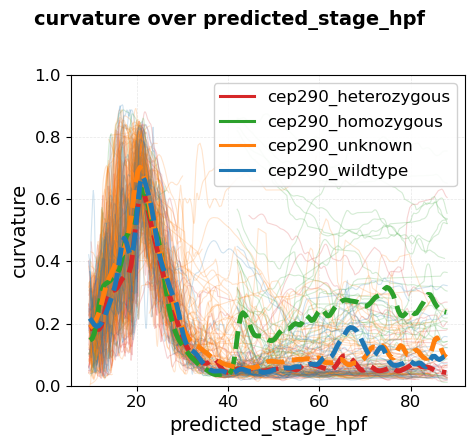

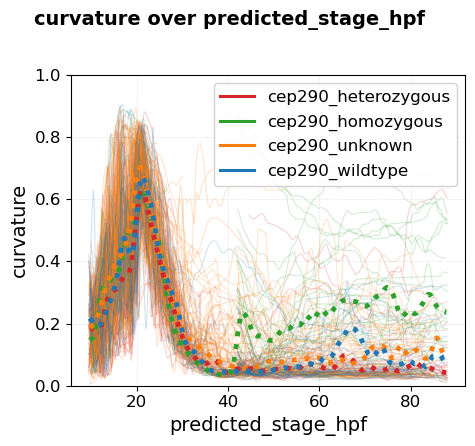

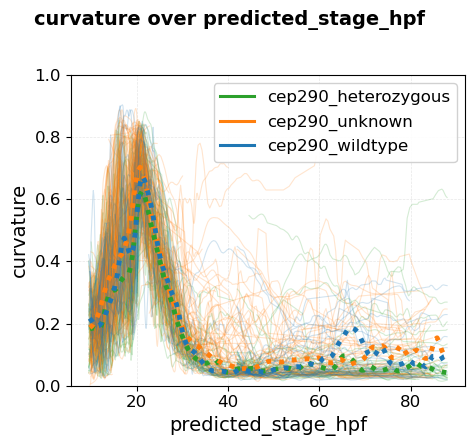

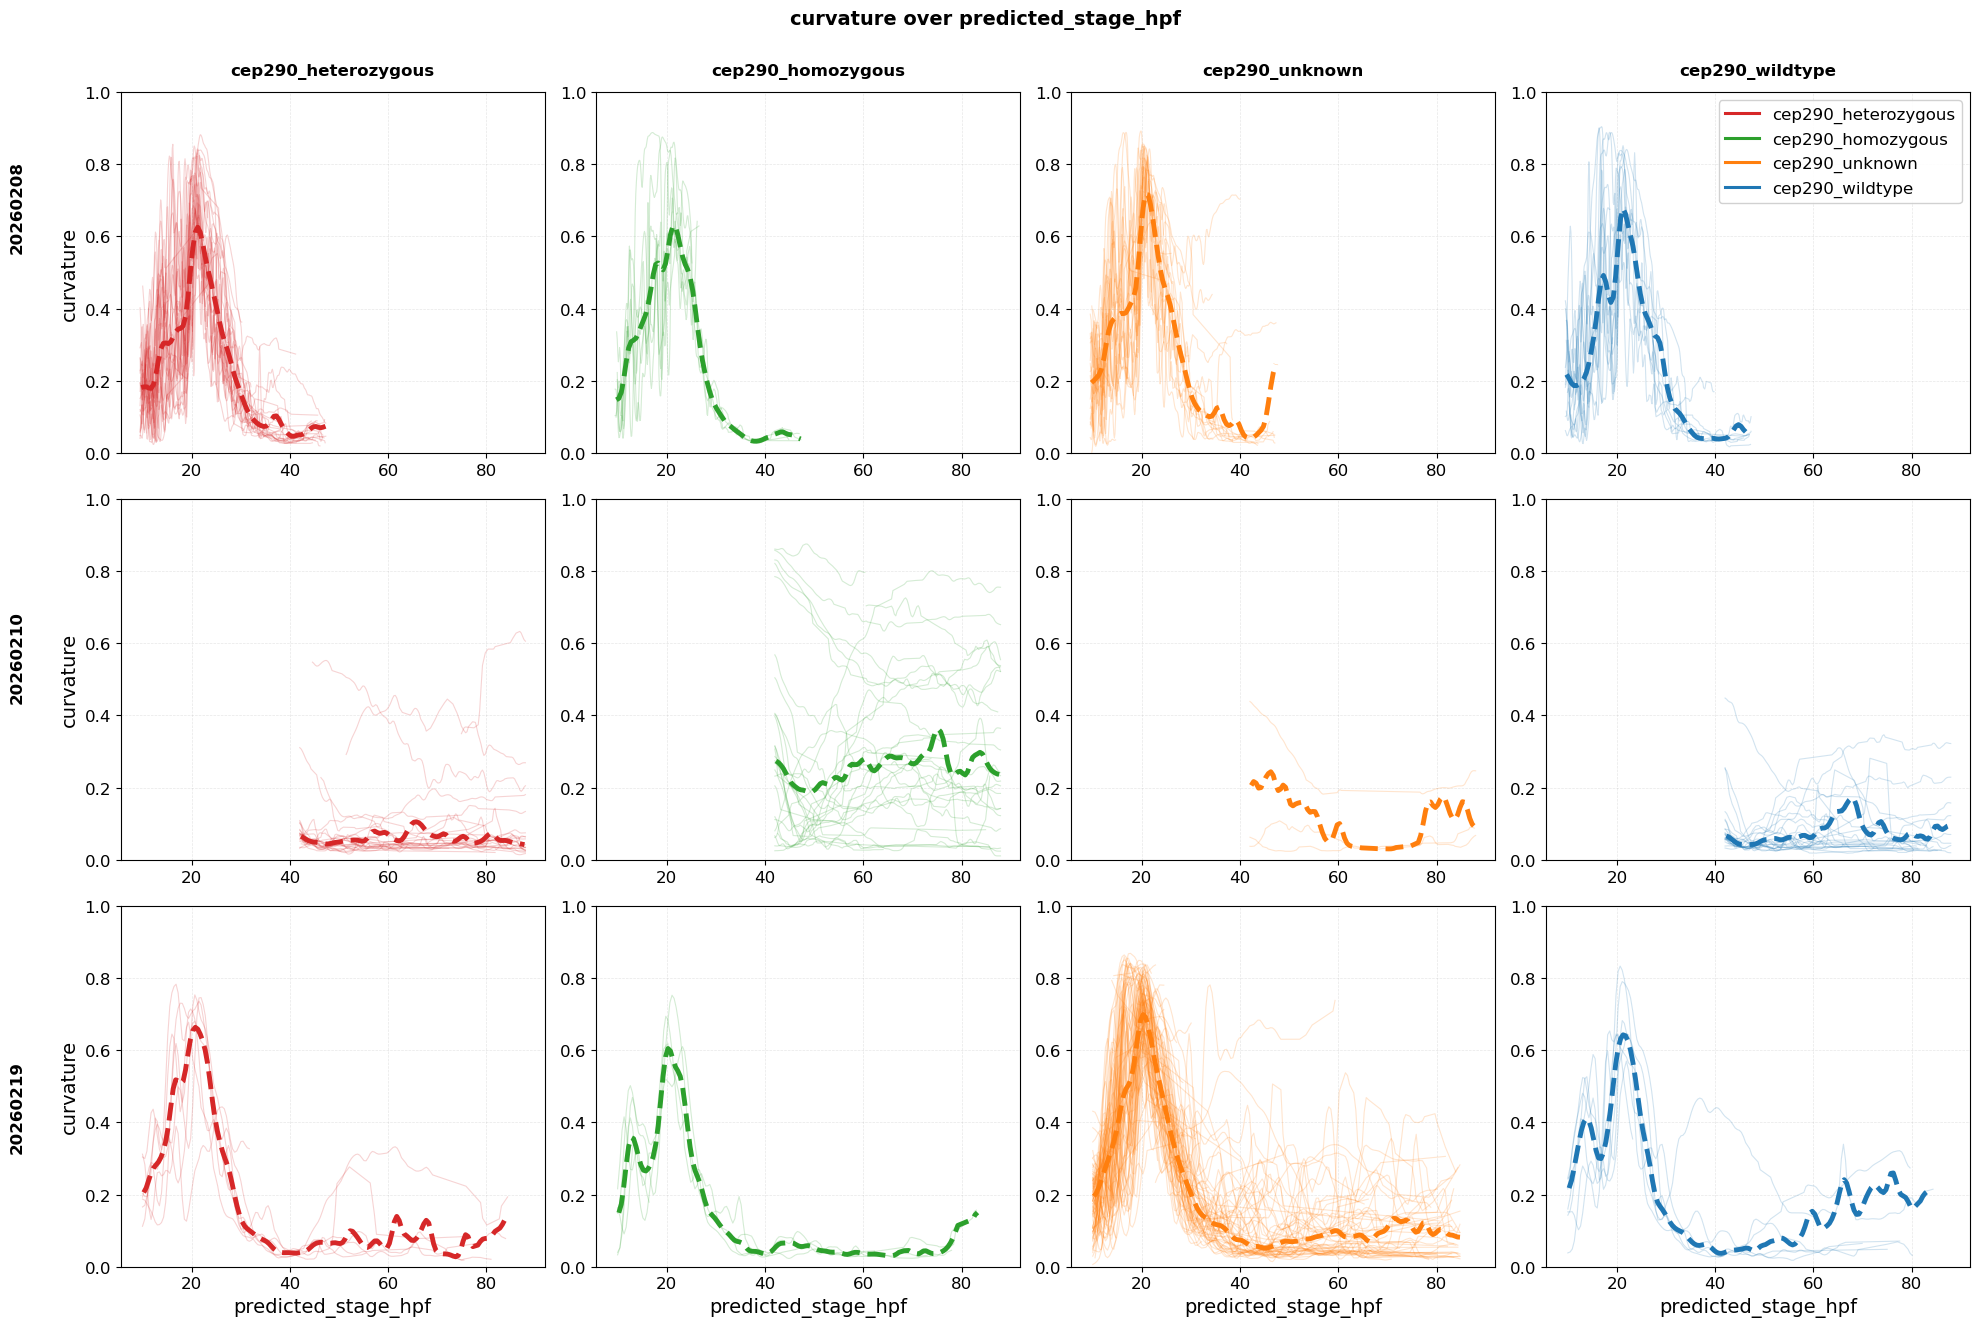

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import analyze.viz.plotting.feature_over_time as feature_over_time
importlib.reload(feature_over_time)
from analyze.viz.plotting.feature_over_time import plot_feature_over_time


# -----------------------------
# 1) Genotype palette (ordinal gradient: cool -> warm -> hot)
# -----------------------------
ROSE_TEAL_CHARCOAL = {
    "High_to_Low":   "#E76FA2",  # brighter rose
    "Low_to_High":   "#2FB7B0",  # brighter teal
    "Not Penetrant": "#3A3A3A",  # charcoal anchor
}

PHENOTYPE_COLORS = ROSE_TEAL_CHARCOAL

df_ref = df
# -----------------------------
# 3) Your examples (unchanged structure)
# -----------------------------
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Example 1: Single feature — curvature by genotype
figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    color_by="genotype",
    # color_lookup=GENOTYPE_COLORS,
    ylim=(0, 1.0),
    backend="matplotlib",
    trend_linestyle='dashed',
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()


# Example 1: Single feature — curvature by genotype
figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    color_by="genotype",
    # color_lookup=GENOTYPE_COLORS,
    ylim=(0, 1.0),
    backend="matplotlib",
    trend_linestyle='dotted',
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()

figs = plot_feature_over_time(
    df_ref[df_ref["genotype"]!="cep290_homozygous"],
    features="curvature",
    color_by="genotype",
    # color_lookup=GENOTYPE_COLORS,
    ylim=(0, 1.0),
    backend="matplotlib",
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()


# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()

figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    facet_col="genotype",
    facet_row= "experiment_id",
    color_by="genotype",
    # color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    trend_linestyle='dashed',
    ylim=(0, 1.0),
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()


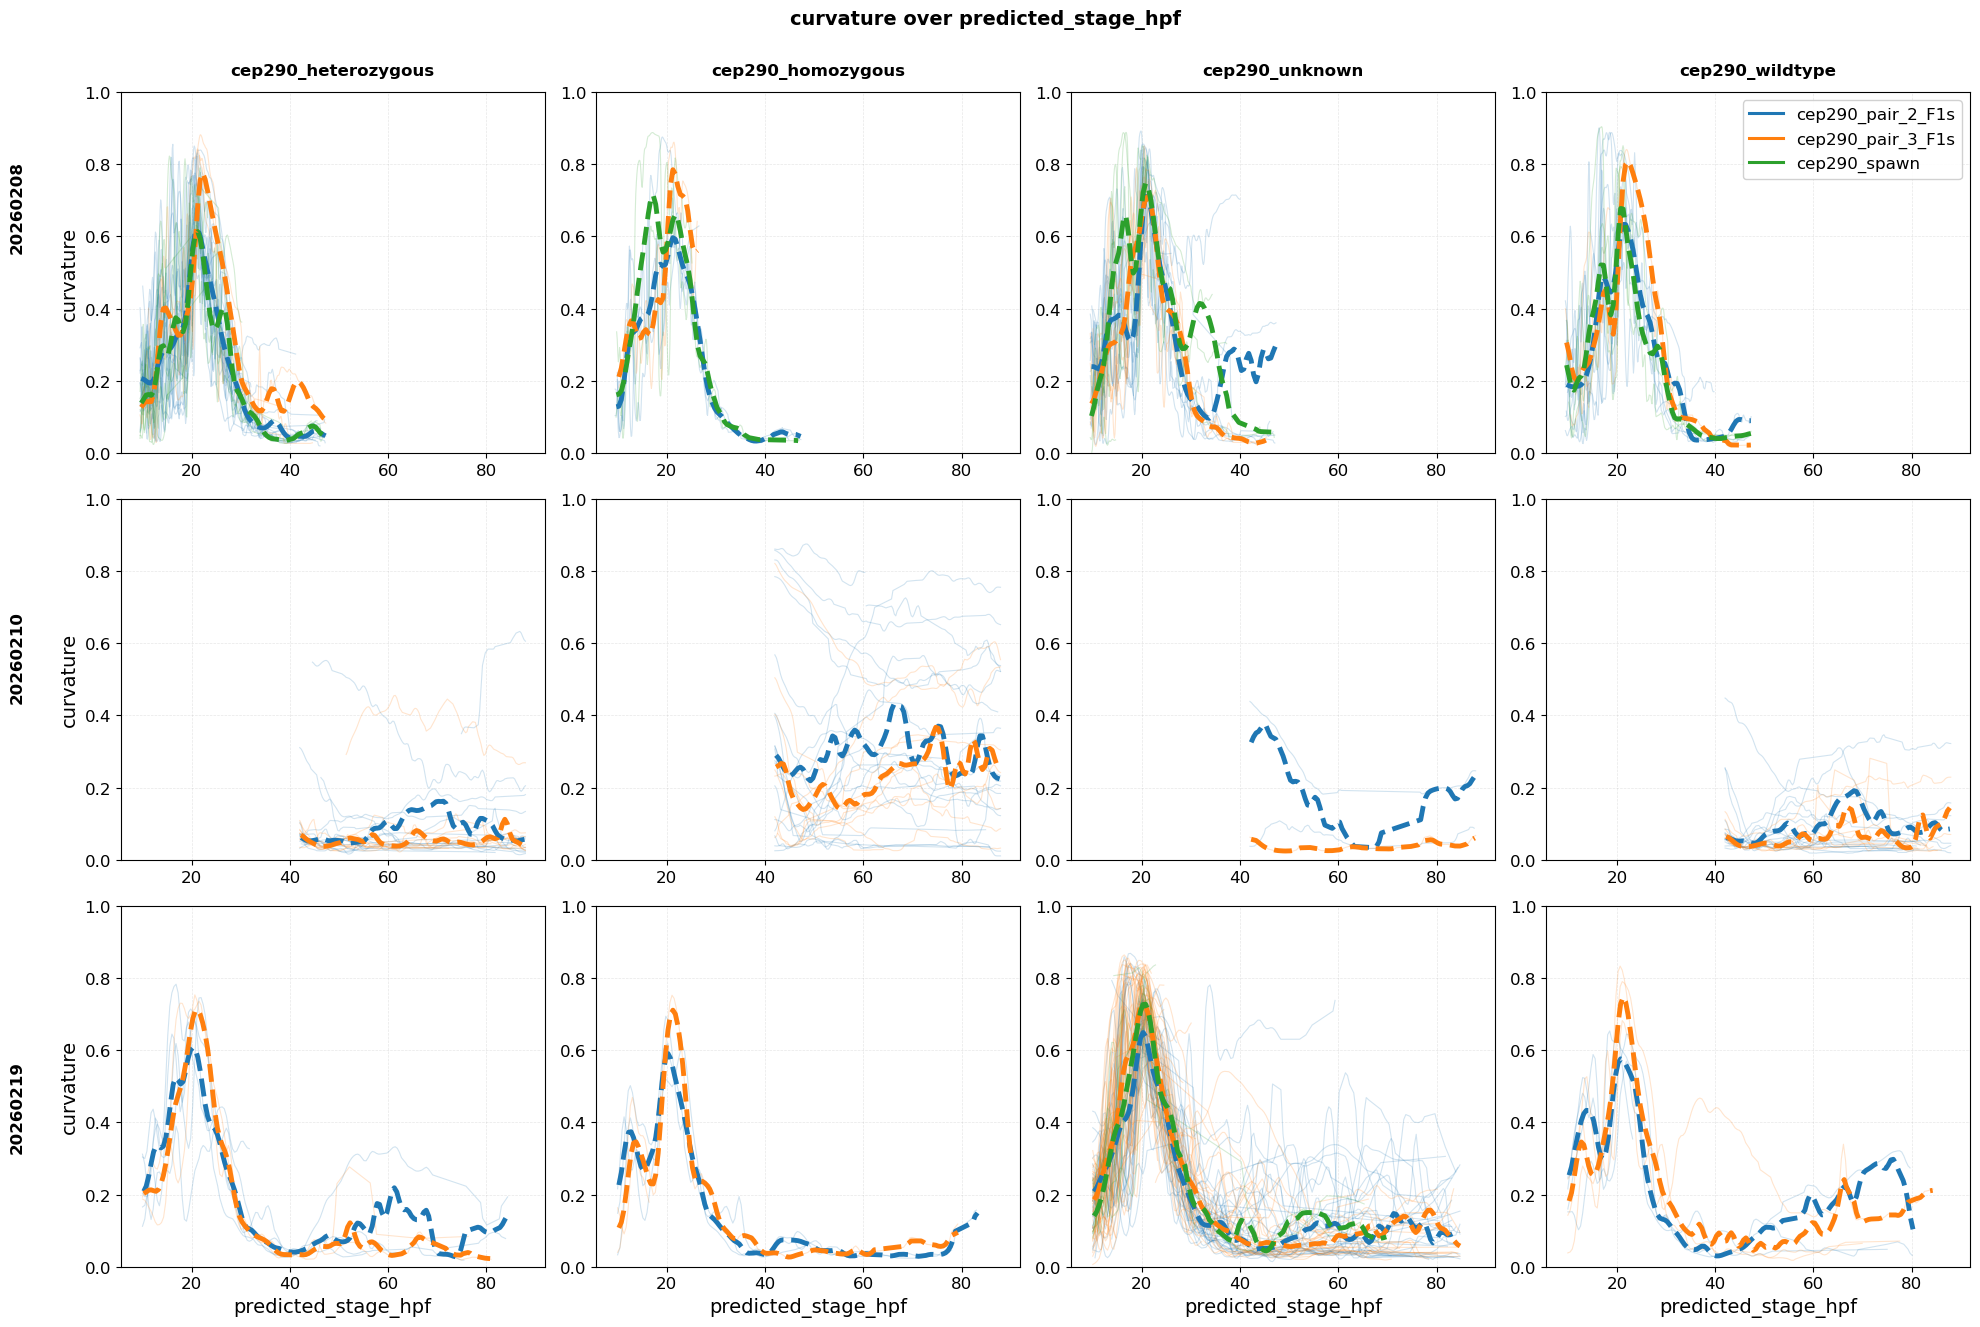

In [6]:
figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    facet_col="genotype",
    facet_row= "experiment_id",
    color_by="pair",
    # color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    trend_linestyle='dashed',
    ylim=(0, 1.0),
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()


In [41]:
import sys, importlib
from pathlib import Path

# Make sure you're importing the repo copy (src/) not a site-packages install
src = str(Path.cwd() / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()

# Reload the modules you actually changed (renderers) + the caller
import analyze.viz.plotting.faceting_engine.renderers.matplotlib as mpl_renderer
import analyze.viz.plotting.faceting_engine.renderers.plotly as plotly_renderer
import analyze.viz.plotting.faceting_engine as faceting_engine
import analyze.viz.plotting.feature_over_time as feature_over_time

for m in (mpl_renderer, plotly_renderer, faceting_engine, feature_over_time):
    importlib.reload(m)

plot_feature_over_time = feature_over_time.plot_feature_over_time
print("loaded from:", feature_over_time.__file__)


loaded from: /net/trapnell/vol1/home/mdcolon/proj/morphseq/src/analyze/viz/plotting/feature_over_time.py


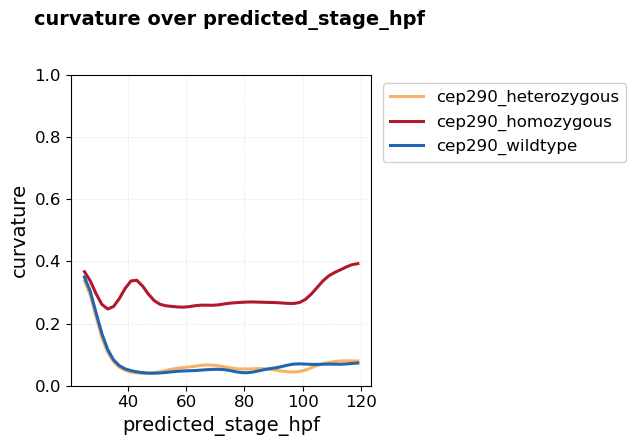

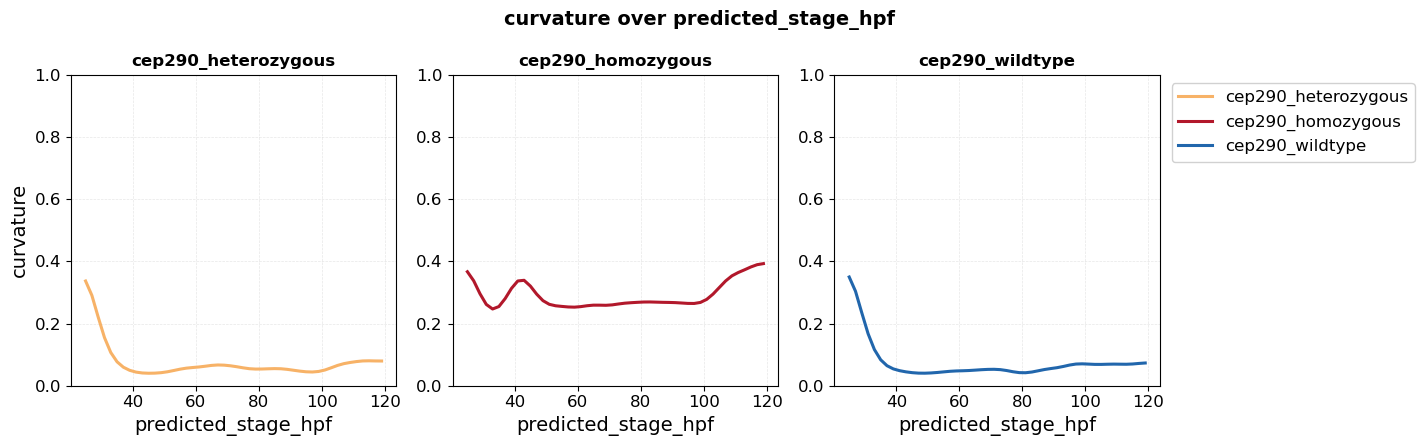

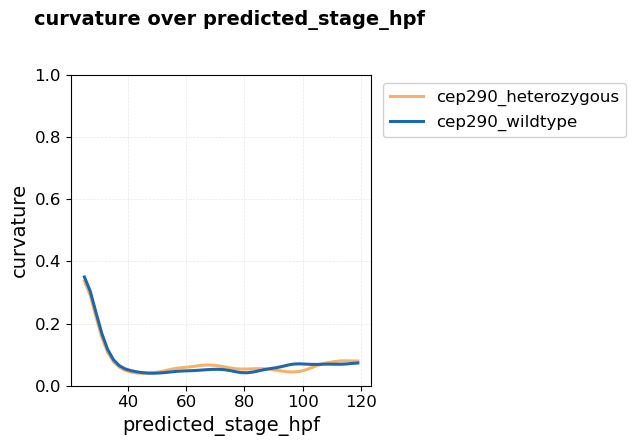

In [70]:
from pathlib import Path
import matplotlib.pyplot as plt
import importlib


# -----------------------------
# 1) Genotype palette (ordinal gradient: cool -> warm -> hot)
# -----------------------------
ROSE_TEAL_CHARCOAL = {
    "High_to_Low":   "#E76FA2",  # brighter rose
    "Low_to_High":   "#2FB7B0",  # brighter teal
    "Not Penetrant": "#3A3A3A",  # charcoal anchor
}

PHENOTYPE_COLORS = ROSE_TEAL_CHARCOAL


# -----------------------------
# 3) Your examples (unchanged structure)
# -----------------------------
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    color_by="genotype",
    color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    show_individual=False,
    show_error_band=False,
    bin_width=2,
    ylim=(0, 1.0),
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
plt.show()


# Example 1: Single feature — curvature by genotype
figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    color_by="genotype",
    facet_col="genotype",
    color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    show_individual=False,
    show_error_band=False,
    bin_width=2,
    ylim=(0, 1.0),
)


figs = plot_feature_over_time(
    df_ref[df_ref["genotype"]!="cep290_homozygous"],
    features="curvature",
    color_by="genotype",
    color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    show_individual=False,
    show_error_band=False,
    bin_width=2,
    ylim=(0, 1.0),

)



# focus on cluster categories 

In [74]:
fig = plot_proportions(
    df_ref,
    color_by_grouping="cluster_lables",
    row_by="genotype",
    col_by="experiment_id",
    count_by="embryo_id",
    normalize=True,
    bar_mode="grouped",
    title="Cluster Distribution by Experiment and Genotype",
    show_counts=True,
)
plt.show()

KeyError: 'cluster_lables'

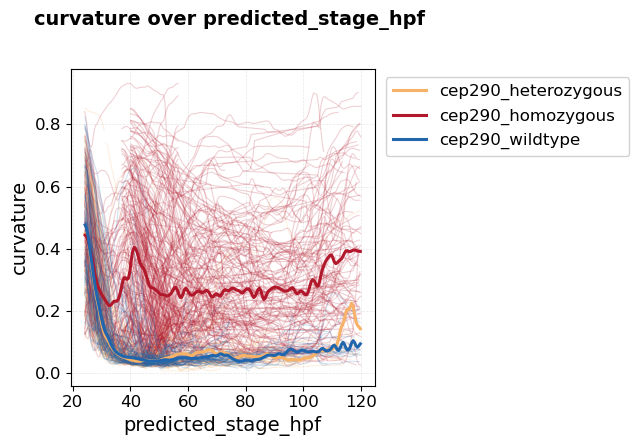

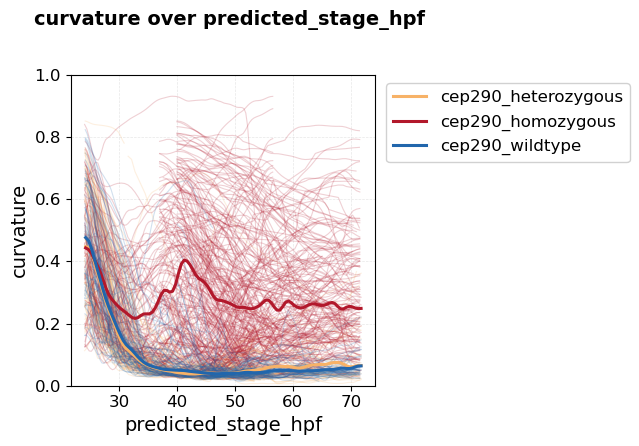

In [67]:
# Example 1: Single feature — curvature by genotype
figs = plot_feature_over_time(
    df_ref,
    features="curvature",
    color_by="genotype",
    color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
)
# If your function returns both backends, keep these lines.
# If not, just comment out the plotly ones.
for ax in figs.axes:
    ax.tick_params(axis="both", which="major", labelsize=12)  # x+ y tick font size
    ax.tick_params(axis="both", which="minor", labelsize=12)  # optional
    
    # ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    # ax.set_ylabel(ax.get_ylabel(), fontsize=14)
plt.show()



df_ref["predicted_stage_hpf"] >= 24


figs = plot_feature_over_time(
    df_ref[df_ref["predicted_stage_hpf"] < 72],
    features="curvature",
    color_by="genotype",
    color_lookup=GENOTYPE_COLORS,
    backend="matplotlib",
    ylim=(0, 1.0)
)
plt.show()

## Feature-Over-Time Plotting

most efficient way to look at features overtime (e.g. curvsture, embedding distance, etc) is to plot them over time with one line per embryo and a smoothed trend line. This allows you to see both the overall trend and the variability across embryos.

`plot_feature_over_time(df, features, ...)` plots one or more metrics over developmental time with per-embryo traces and a smoothed trend line.

**Key parameters:**

| Parameter | Default | Description |
|---|---|---|
| `features` | *(required)* | `str` or `list[str]`. Single feature plots one panel; a list creates one row per feature. |
| `color_by` | `None` | Column to color traces by (e.g. `"genotype"`, `"pair"`). |
| `color_lookup` | `None` | `dict` mapping `color_by` values to hex colors. Auto-assigns if omitted. |
| `facet_row` | `None` | Column to split into subplot rows (e.g. `"experiment_id"`). |
| `facet_col` | `None` | Column to split into subplot columns (e.g. `"genotype"`). |
| `backend` | `"plotly"` | `"plotly"` (interactive), `"matplotlib"` (static), or `"both"` (returns dict). |
| `show_individual` | `True` | Show per-embryo trajectory lines. |
| `show_error_band` | `False` | Show error band around trend line. |
| `error_type` | `"iqr"` | Error measure: `"iqr"`/`"mad"` for median, `"sd"`/`"se"` for mean. |
| `trend_statistic` | `"median"` | Central tendency: `"median"` or `"mean"`. |
| `trend_smooth_sigma` | `1.5` | Gaussian smoothing sigma for the trend line. |
| `bin_width` | `0.5` | Time bin width (hpf) for aggregating the trend. |
| `smooth_method` | `"gaussian"` | Smoothing for individual traces (`None` to disable). |

**Return value:** With `backend="both"`, returns `{"plotly": fig, "matplotlib": fig}`. Otherwise returns a single figure.

**Faceting behavior:** When `features` is a list, each feature becomes its own row automatically. `facet_row` and `facet_col` add additional grid dimensions from data columns.

## PCA & 3D Scatter

Reduce VAE latent dimensions with PCA and visualize embryo trajectories in 3D space. `fit_transform_pca()` auto-detects `z_mu_b_*` columns; `plot_3d_scatter()` supports both categorical and continuous coloring.

## DTW Clustering

Cluster embryo trajectories by shape similarity using MD-DTW distance and k-medoids.

**Pipeline:**
`HPF Coverage Check` → `Distance Matrix` → `K-Selection` → `Apply Clusters`

| Step | Function | Key Parameters |
|------|----------|---------------|
| 1. HPF overlap | `plot_experiment_time_coverage()` + `plot_hpf_overlap_quick()` | `bin_width=0.5`, `min_embryos_per_bin=3`, `min_experiments=2` |
| 2. Distance matrix | `compute_trajectory_distances()` | `metrics` (one or more features), `time_window`, `normalize=True`, `sakoe_chiba_radius=20` |
| 3. K-selection | `run_k_selection_with_plots()` | `k_range`, `n_bootstrap` (20 for speed, 100+ for production), `method="kmedoids"` |

**Hints:**
- **HPF window**: Auto-detection can be unreliable with batch effects — override manually if needed.
- **Features**: `metrics` accepts a single feature or a list. A single feature gives standard DTW; a list gives multidimensional DTW (e.g. curvature + length jointly).
- **Warping**: `sakoe_chiba_radius=20` constrains alignment flexibility. Lower = stricter temporal matching.
- **Speed**: `n_bootstrap=20` is fast for exploration. Use 100+ for publication figures. Distance matrix and k-selection both support `n_jobs=-1` for multi-CPU parallelization.
- **Output**: `cluster_assignments.csv` contains labels for every k in `k_range`.

In [ ]:
from analyze.trajectory_analysis.utilities.dtw_utils import compute_trajectory_distances
from analyze.trajectory_analysis.clustering import run_k_selection_with_plots
from analyze.viz.hpf_coverage import plot_experiment_time_coverage, plot_hpf_overlap_quick

# HPF coverage check
bins_mid, cover_df, cov_count = plot_experiment_time_coverage(
    df, experiment_col="experiment_id", hpf_col="predicted_stage_hpf",
    embryo_col="embryo_id", bin_width=0.5, min_embryos_per_bin=3,
)
hpf_start, hpf_end = plot_hpf_overlap_quick(
    bins_mid, cov_count, cover_df=cover_df, min_experiments=2,
    show_heatmap=True,
    coverage_plot_path=FIGURES_DIR / "notebook_03_hpf_coverage.png",
    heatmap_path=FIGURES_DIR / "notebook_03_hpf_heatmap.png",
    show=True,
)
# Override — batch effects in staging can make auto-detection unreliable
hpf_start, hpf_end = 25, 50
time_window = (hpf_start, hpf_end)
print(f"HPF window: {hpf_start}–{hpf_end}")

### Compute Distance Matrix

In [ ]:
# Compute MD-DTW distance matrix
FEATURES = ["baseline_deviation_normalized"]
D, embryo_ids, time_grid = compute_trajectory_distances(
    df, 
    metrics=FEATURES, 
    time_col="predicted_stage_hpf",
    time_window=time_window, 
    embryo_id_col="embryo_id",
    normalize=True,
    sakoe_chiba_radius=20, 
    verbose=True,
)
print(f"Distance matrix: {D.shape}, range [{D.min():.2f}, {D.max():.2f}]")

### K-Selection

Run bootstrap stability analysis to choose the optimal number of clusters.

**Key parameters:**
- `method`: Clustering algorithm. Options: `"kmedoids"` (preferred, robust to outliers) or `"hierarchical"`.
- `n_bootstrap`: Number of bootstrap resamples for stability analysis. Use 20 for exploration, 100+ for production.
- `k_range`: List of k values to test (e.g., `[2, 3, 4, 5, 6]`).
- `plotting_metrics`: Features to plot in cluster trajectories (can differ from distance metrics).
- `enable_stage1_filtering`: Whether to apply outlier filtering before clustering (default: `True`).
- `stage1_method`: Outlier detection method (`"iqr"` or `"knn"`). Default: `"iqr"`.

**Outputs saved to `output_dir`:**
- `cluster_assignments.csv`: Cluster labels for all k values tested
- `silhouette_scores.png`: Silhouette scores by k
- `stability_heatmap.png`: Bootstrap stability matrix
- `cluster_flow_sankey.html`: Interactive Sankey diagram showing cluster reassignments across k
- `k_{k}/`: Per-k subdirectories with trajectory plots

### Apply Clusters

Choose your k from the selection above, or subset and recluster as needed.

## Classification Tests

Run permutation-based classification tests to quantify phenotypic differences between clusters:
- **Mode 1: One-vs-Rest** — How distinguishable is each cluster from all others?
- **Mode 2: vs Not Penetrant** — How different is each mutant cluster from wild-type-like embryos?
- **Mode 3: Crispant vs Homozygous (negative control)** — Within the same phenotypic cluster, crispants and homozygous mutants should be indistinguishable (AUROC ~0.5).
- **Mode 4: ab vs Wildtype (negative control)** — Two wildtype strains from different genetic backgrounds should also be indistinguishable (AUROC ~0.5).

Three feature sets are compared: curvature, body length, and VAE embedding.

Permutation count is reduced for speed (`n_permutations=50`). For production, use 200+.

**Caveat**: Modes 3/4 combine data across experiments. VAE batch effects inflate embedding AUROCs (~0.8) even for expected-null comparisons. Curvature-only controls are more reliable.